{'topic': '猫咪', 'poem': '## 《猫》\n\n它就要跳上你的膝盖，你无法拒绝\n它选择谁就是谁的恩典\n当它离开，留下余温\n和几根银白的针\n\n它跃上书架，碰落\n去年夹在书页里的枯叶\n像某个迟到的下午\n突然归还的诺言\n\n它凝视窗外，仿佛那里\n有另一个自己，正转身离去\n而你们共同拥有过的黑暗\n比任何抚摸都深', 'joke': '好的，来一个猫咪主题的冷笑话：\n\n**《快递员与猫》**\n\n快递员按响门铃，一只猫叼着包裹签收单开了门。\n\n快递员震惊：“你……你会开门？还会签收？”\n\n猫淡定地说：“喵。”\n\n快递员更震惊了：“你还会说人话？！”\n\n猫叹了口气：“废话，我都在这家干了三年了。这家人以为养的是宠物，其实我才是房东。他们每个月工资一发，第一件事就是给我买罐头、猫砂和逗猫棒。你以为这房子是他们的？房产证上写的是我的名字。”\n\n快递员愣了半天：“那……那你为什么还要亲自签收快递？”\n\n猫翻了个白眼：“因为那个蠢主人又买了一个猫窝。我签收一下，确认退货地址没写错——这已经是这个月第三个了。我跟他说过多少次了，我只需要纸箱，不需要窝。”\n\n说完，猫把签收单递回去，用爪子指了指楼道里的纸箱：“对了，那个纸箱帮我搬进来，那才是我的真·快递。”'}


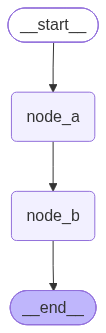

In [1]:
from typing import TypedDict
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from IPython.display import display
load_dotenv(override=True)
model=ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thingking":{
            "type":"disabled"
        }
    }
)
#1. 定义状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
#2. 定义节点
def node_a(state: OverAllState) -> OverAllState:
    poem=model.invoke([f"写一首关于{state['topic']}主题的诗"]).content
    return{
        "poem":poem
    }
def node_b(state:OverAllState)->OverAllState:
    joke=model.invoke([f"写一个关于{state['topic']}主题的笑话"]).content
    return{
        "joke":joke
    }
#3. 构建图
builder=StateGraph(state_schema=OverAllState)
builder.add_node(node_a)
builder.add_node(node_b)
builder.add_edge(START,"node_a")
builder.add_edge("node_a","node_b")
builder.add_edge("node_b",END)

graph=builder.compile()
res=graph.invoke({"topic":"猫咪"})
print(res)
display(graph)

{'topic': '猫咪', 'poem': '## 《猫之书》\n\n chapter 1\n某夜，我拆开毛线球，放走月光的银鱼\n它们游过地板缝隙，在窗帘背面\n产下成串的呼噜。每个音节都让你\n在睡梦中，用肉垫\n在天空按下梅花印章\n\n chapter 2\n打翻牛奶的清晨，你推着瓷碗边缘\n画出完美的圆。液态的钟表\n在餐桌下重新凝固。胡须丈量过\n所有纬线，却总在\n第三根处弯折成问号\n\n chapter 3\n他们说你追咬自己尾巴，是在练习\n无限。而我只看见\n毛茸茸的陀螺，在客厅中央\n把时间卷成会发光的\n毛球。当尾巴尖颤动\n整个宇宙开始倒带\n\n chapter 4\n你总在子夜跑酷，踩着我的肋骨\n飞向冰箱顶端。那些被碰落的\n药瓶与诗稿，在黑暗中\n重新排列成\n你瞳孔里的竖瞳\n\n chapter 5\n九个分身同时跃起，在沙发与书架之间\n留下残影。我数到第七个\n就忘了起点。而你早已\n在窗台收拢翅膀，用尾巴\n圈住所有未完成的\n跳跃\n\n chapter 6\n雪落时你化身墨点，在宣纸般的\n庭院留下足迹。那是写给春天的\n密信，每个字都\n在融化前，被麻雀\n衔去装订成\n会发芽的\n逗号\n\n chapter 7\n你教我喝水的正确姿势：用舌尖\n轻触水面，而不是\n把整张脸埋进碗里。就像\n对待月光，要小口\n啜饮，让凉意\n在胡须上\n结出\n霜花\n\n chapter 8\n如今你老了，总在午后\n把身体摊成液体。阳光流过你\n像流过千年琥珀。而我知道\n某个午夜，你会突然\n起身，抖落\n满身星尘\n纵身跃入\n墙上那幅\n从未存在的\n窗', 'joke': '猫妈妈问小猫：“你为什么总把主人的杯子往桌下推？”\n\n小猫一本正经：“我在做重力实验。”\n\n猫妈妈：“结果呢？”\n\n小猫：“重力一直有效，就是铲屎官的尖叫声每次都不一样。”'}


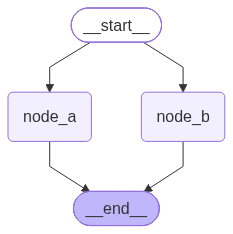

In [2]:
from typing import TypedDict
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from IPython.display import display
load_dotenv(override=True)
model=ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thingking":{
            "type":"disabled"
        }
    }
)
#1. 定义状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
#2. 定义节点
def node_a(state: OverAllState) -> OverAllState:
    poem=model.invoke([f"写一首关于{state['topic']}主题的诗"]).content
    return{
        "poem":poem
    }
def node_b(state:OverAllState)->OverAllState:
    joke=model.invoke([f"写一个关于{state['topic']}主题的笑话"]).content
    return{
        "joke":joke
    }
#3. 构建图
builder=StateGraph(state_schema=OverAllState)
builder.add_node(node_a)
builder.add_node(node_b)
builder.add_edge(START,"node_a")
builder.add_edge(START,"node_b")
builder.add_edge("node_a",END)
builder.add_edge("node_b",END)

graph=builder.compile()
res=graph.invoke({"topic":"猫咪"})
print(res)
display(graph)